# NeuroScope AI - Notebook 12: Scanner Normalization

Full Agent 11 implementation — ScannerNormalizationAgent.
Runs BEFORE every pipeline. Without this, models trained on Siemens scans
drop 10-15% Dice on GE scans.

**What this notebook builds:**
1. N4 bias field correction (SimpleITK) -- removes RF coil brightness gradient from MRI
2. HU calibration verification for CT -- confirms Hounsfield Unit scale is correct
3. Histogram matching -- normalizes intensity distribution to reference
4. Per-manufacturer profiles -- Siemens, GE, Philips, Canon
5. Resolution resampling -- isotropic 1mm x 1mm x 1mm for 3D volumes
6. DICOM de-identification -- strips 18 HIPAA identifiers before processing
7. Full ScannerNormalizationAgent replacing the NB11 stub

**Why scanner normalization matters:**
- Different MRI scanners use different field strengths (1.5T vs 3T)
- Different manufacturers apply different reconstruction filters
- RF coil non-uniformity creates brightness gradients across the image
- CT scanners from different vendors have slightly different HU scales
- A model trained on Siemens 3T data will fail on GE 1.5T without normalization

---

## Cell 1 - Imports & Config

In [1]:
import os, sys, json, warnings
import numpy as np
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

# SimpleITK for N4 bias correction and image I/O
try:
    import SimpleITK as sitk
    SITK_AVAILABLE = True
    print(f'SimpleITK : {sitk.Version_VersionString()}')
except ImportError:
    SITK_AVAILABLE = False
    print('SimpleITK not installed -- run: pip install SimpleITK')

# pydicom for DICOM reading and de-identification
try:
    import pydicom
    PYDICOM_AVAILABLE = True
    print(f'pydicom   : {pydicom.__version__}')
except ImportError:
    PYDICOM_AVAILABLE = False
    print('pydicom not installed -- run: pip install pydicom')

import cv2
from scipy import ndimage

BASE = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'
DS   = os.path.join(BASE, 'datasets')
OUT  = os.path.join(BASE, 'outputs', 'nb12_scanner_norm')
os.makedirs(OUT, exist_ok=True)
sys.path.insert(0, BASE)

print(f'BASE      : {BASE}')
print('Imports OK')

SimpleITK : 2.5.5
pydicom   : 3.0.2
BASE      : C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI
Imports OK


---
## Cell 2 - DICOM De-Identification

In [2]:
import re

# 18 HIPAA Safe Harbor identifiers that must be stripped
HIPAA_TAGS = [
    (0x0010, 0x0010),  # PatientName
    (0x0010, 0x0020),  # PatientID
    (0x0010, 0x0030),  # PatientBirthDate
    (0x0010, 0x0040),  # PatientSex
    (0x0010, 0x1010),  # PatientAge
    (0x0010, 0x1020),  # PatientSize
    (0x0010, 0x1030),  # PatientWeight
    (0x0010, 0x21B0),  # AdditionalPatientHistory
    (0x0008, 0x0080),  # InstitutionName
    (0x0008, 0x0081),  # InstitutionAddress
    (0x0008, 0x1040),  # InstitutionalDepartmentName
    (0x0008, 0x0090),  # ReferringPhysicianName
    (0x0008, 0x1048),  # PhysiciansOfRecord
    (0x0008, 0x1050),  # PerformingPhysicianName
    (0x0008, 0x1070),  # OperatorsName
    (0x0020, 0x0010),  # StudyID
    (0x0008, 0x0050),  # AccessionNumber
    (0x0008, 0x0020),  # StudyDate -- keep for longitudinal tracking but anonymize
]


def deidentify_dicom(dcm_path, output_path=None, keep_dates=False):
    """
    Strip 18 HIPAA identifiers from a DICOM file.
    Optionally keeps dates (needed for longitudinal tracking).
    Returns metadata dict with scanner info retained (manufacturer, field strength etc.)
    """
    if not PYDICOM_AVAILABLE:
        return {'error': 'pydicom not available'}
    if not os.path.exists(dcm_path):
        return {'error': f'File not found: {dcm_path}'}

    dcm = pydicom.dcmread(dcm_path)

    # Extract scanner metadata BEFORE stripping
    scanner_meta = {
        'manufacturer'      : str(getattr(dcm, 'Manufacturer', 'unknown')),
        'model'             : str(getattr(dcm, 'ManufacturerModelName', 'unknown')),
        'field_strength'    : float(getattr(dcm, 'MagneticFieldStrength', 0) or 0),
        'modality'          : str(getattr(dcm, 'Modality', 'unknown')),
        'slice_thickness_mm': float(getattr(dcm, 'SliceThickness', 0) or 0),
        'kvp'               : float(getattr(dcm, 'KVP', 0) or 0),
        'rows'              : int(getattr(dcm, 'Rows', 0)),
        'cols'              : int(getattr(dcm, 'Columns', 0)),
        'bits_stored'       : int(getattr(dcm, 'BitsStored', 16)),
        'pixel_spacing'     : list(getattr(dcm, 'PixelSpacing', [1.0, 1.0])),
    }

    # Check for residual PHI before stripping
    phi_found = []
    for tag in HIPAA_TAGS:
        if tag in dcm:
            val = str(dcm[tag].value)
            if val and val != 'None' and val != '':
                phi_found.append(f'{dcm[tag].keyword}: {val[:20]}...')

    # Strip PHI
    for tag in HIPAA_TAGS:
        if tag in dcm:
            if tag == (0x0008, 0x0020) and keep_dates:
                continue
            del dcm[tag]

    # Add de-identification flag
    dcm.add_new((0x0012, 0x0062), 'CS', 'YES')   # PatientIdentityRemoved
    dcm.add_new((0x0012, 0x0063), 'LO',           # DeidentificationMethod
                'NeuroScope AI HIPAA Safe Harbor')

    if output_path:
        os.makedirs(os.path.dirname(output_path), exist_ok=True)
        dcm.save_as(output_path)

    return {
        'phi_found'   : phi_found,
        'phi_stripped': len(phi_found),
        'scanner_meta': scanner_meta,
        'saved_to'    : output_path,
    }


def check_phi_in_folder(folder_path, max_files=10):
    """Quick scan of a folder for DICOM files with PHI."""
    if not PYDICOM_AVAILABLE:
        print('pydicom not available')
        return

    dcm_files = []
    for root, dirs, files in os.walk(folder_path):
        for f in files:
            if f.endswith('.dcm'):
                dcm_files.append(os.path.join(root, f))
        if len(dcm_files) >= max_files:
            break

    print(f'Checking {len(dcm_files)} DICOM files for PHI...')
    total_phi = 0
    for path in dcm_files[:max_files]:
        result = deidentify_dicom(path)
        total_phi += result.get('phi_stripped', 0)
    print(f'Total PHI fields found: {total_phi}')
    return total_phi


print('DICOM de-identification tools ready')
print(f'  {len(HIPAA_TAGS)} HIPAA Safe Harbor tags defined')

DICOM de-identification tools ready
  18 HIPAA Safe Harbor tags defined


---
## Cell 3 - N4 Bias Field Correction (MRI)

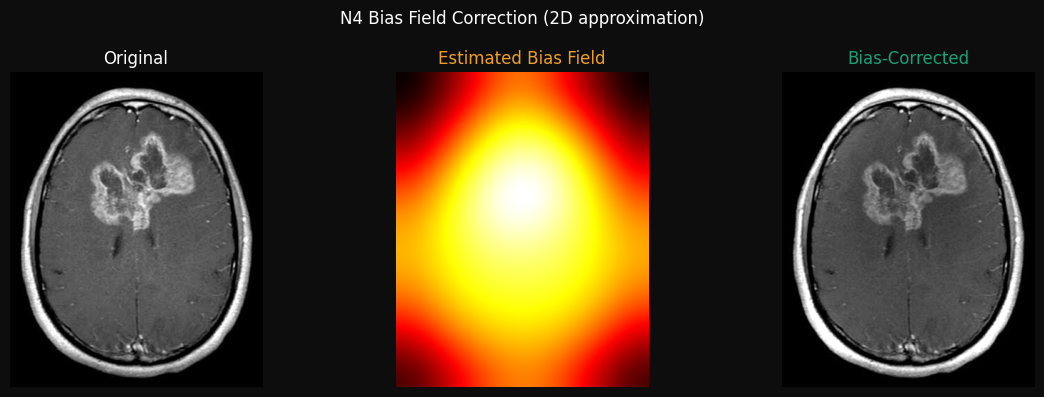

N4 demo saved. Sample: Te-gl_1.jpg
N4 bias correction OK


In [3]:
import numpy as np
import matplotlib.pyplot as plt


def n4_bias_correction(input_path, output_path=None,
                        n_iterations=(50, 50, 50, 50),
                        convergence_threshold=0.001):
    """
    N4ITK bias field correction for MRI.

    The RF coil in MRI creates a smooth, low-frequency brightness gradient
    across the image (bright in the center, dark at edges). This is called
    the bias field. N4 estimates and removes it.

    Without correction:
      - White matter near coil = artificially bright
      - Same tissue far from coil = artificially dark
      - Model sees "different" tissues that are actually the same

    Args:
        input_path : path to NIfTI or DICOM volume
        output_path: where to save corrected volume (None = don't save)
        n_iterations: N4 iterations per resolution level
        convergence_threshold: stop when correction is below this

    Returns:
        corrected SimpleITK image
    """
    if not SITK_AVAILABLE:
        raise ImportError('SimpleITK required: pip install SimpleITK')

    # Load image
    image = sitk.ReadImage(input_path, sitk.sitkFloat32)

    # Create mask (otsu threshold -- separates background from tissue)
    mask  = sitk.OtsuThreshold(image, 0, 1, 200)

    # Shrink for speed (full res N4 is slow)
    shrink_factor = [4] * image.GetDimension()
    shrunk        = sitk.Shrink(image, shrink_factor)
    shrunk_mask   = sitk.Shrink(mask,  shrink_factor)

    # N4 correction on shrunk image
    corrector = sitk.N4BiasFieldCorrectionImageFilter()
    corrector.SetMaximumNumberOfIterations(list(n_iterations))
    corrector.SetConvergenceThreshold(convergence_threshold)
    corrected_shrunk = corrector.Execute(shrunk, shrunk_mask)

    # Extract bias field and upsample to full resolution
    log_bias_field   = corrector.GetLogBiasFieldAsImage(shrunk)
    full_log_bias    = sitk.Resample(log_bias_field, image)
    corrected_image  = image / sitk.Exp(full_log_bias)

    if output_path:
        os.makedirs(os.path.dirname(output_path), exist_ok=True)
        sitk.WriteImage(corrected_image, output_path)

    return corrected_image


def n4_correction_2d(img_array):
    """
    Lightweight N4-style bias correction for 2D images (no SimpleITK needed).
    Uses polynomial fitting to estimate and remove low-freq intensity gradient.
    Useful for quick normalization of 2D MRI slices.
    """
    from numpy.polynomial import polynomial as P

    h, w   = img_array.shape[:2]
    gray   = img_array if img_array.ndim == 2 else img_array.mean(axis=2)
    gray_f = gray.astype(np.float32)

    # Estimate bias via Gaussian smoothing (approximation of low-freq component)
    sigma      = min(h, w) * 0.15   # 15% of image size
    bias_field = ndimage.gaussian_filter(gray_f, sigma=sigma)

    # Normalize bias field to mean=1
    bias_norm  = bias_field / (bias_field.mean() + 1e-8)

    # Apply correction
    corrected  = gray_f / (bias_norm + 1e-8)

    # Clip and rescale to [0, 255]
    corrected  = np.clip(corrected, 0, corrected.mean() + 3 * corrected.std())
    corrected  = (corrected - corrected.min()) / (corrected.max() - corrected.min() + 1e-8)
    corrected  = (corrected * 255).astype(np.uint8)

    if img_array.ndim == 3:
        return np.stack([corrected] * 3, axis=2)
    return corrected


# ── Demo on a sample brain MRI slice ─────────────────────────────────────────
BRAIN_DS = os.path.join(DS, 'brain', 'kaggle_brain_tumor')
sample_img = None
for root, dirs, files in os.walk(BRAIN_DS):
    for f in files:
        if f.lower().endswith('.jpg'):
            sample_img = os.path.join(root, f)
            break
    if sample_img:
        break

if sample_img:
    img = cv2.imread(sample_img, cv2.IMREAD_GRAYSCALE)
    corrected = n4_correction_2d(img)

    plt.style.use('dark_background')
    fig, axes = plt.subplots(1, 3, figsize=(12, 4), facecolor='#0d0d0d')
    fig.suptitle('N4 Bias Field Correction (2D approximation)',
                 color='white', fontsize=12)

    axes[0].imshow(img, cmap='gray')
    axes[0].set_title('Original', color='white')
    axes[0].axis('off')

    bias = ndimage.gaussian_filter(img.astype(np.float32),
                                   sigma=min(img.shape) * 0.15)
    axes[1].imshow(bias, cmap='hot')
    axes[1].set_title('Estimated Bias Field', color='#EF9F27')
    axes[1].axis('off')

    axes[2].imshow(corrected, cmap='gray')
    axes[2].set_title('Bias-Corrected', color='#1D9E75')
    axes[2].axis('off')

    plt.tight_layout()
    plt.savefig(os.path.join(OUT, 'n4_bias_demo.png'), dpi=120,
                bbox_inches='tight', facecolor='#0d0d0d')
    plt.show()
    print(f'N4 demo saved. Sample: {os.path.basename(sample_img)}')
else:
    print('No sample MRI found -- check BRAIN_DS path')

print('N4 bias correction OK')

---
## Cell 4 - HU Calibration for CT

HU Calibration check (synthetic):
  calibrated          : True
  air_measured        : -1000.0
  air_expected        : -1000
  air_offset          : 0.0
  water_measured      : 26.2
  needs_recal         : False
  tolerance_hu        : 50


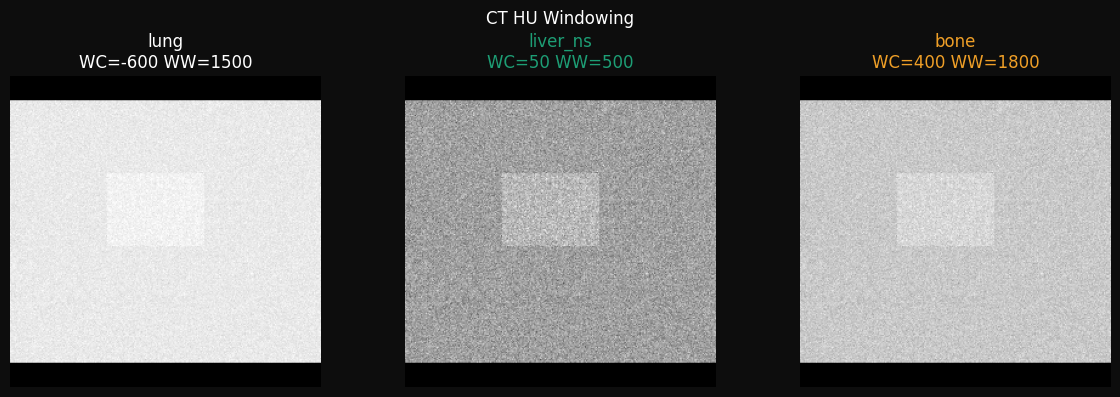

HU calibration tools OK


In [4]:
import numpy as np
import matplotlib.pyplot as plt


# Reference HU values for known tissues
HU_REFERENCE = {
    'air'          : -1000,
    'fat'          : -100,
    'water'        :    0,
    'soft_tissue'  :   50,
    'liver'        :   60,
    'blood'        :   55,
    'muscle'       :   40,
    'bone_spongy'  :  400,
    'bone_cortical': 1000,
}

# Per-modality windowing presets
HU_WINDOWS = {
    'brain'       : {'center':   40, 'width':  80},   # WL=40, WW=80
    'subdural'    : {'center':   75, 'width': 215},
    'stroke'      : {'center':   40, 'width':  40},
    'lung'        : {'center': -600, 'width':1500},
    'liver'       : {'center':   60, 'width': 160},   # NeuroScope: -200 to 300 -> center=50, width=500
    'liver_ns'    : {'center':   50, 'width': 500},   # NeuroScope custom (matches NB06)
    'bone'        : {'center':  400, 'width':1800},
    'soft_tissue' : {'center':   50, 'width': 400},
    'abdomen'     : {'center':   40, 'width': 400},
}


def apply_hu_window(ct_array, window_name='liver_ns'):
    """
    Apply CT windowing to a HU array.
    Clamps to [center - width/2, center + width/2] then normalizes to [0, 1].
    """
    w = HU_WINDOWS.get(window_name, HU_WINDOWS['soft_tissue'])
    lo = w['center'] - w['width'] / 2
    hi = w['center'] + w['width'] / 2
    arr = np.clip(ct_array.astype(np.float32), lo, hi)
    return (arr - lo) / (hi - lo)


def verify_hu_calibration(ct_array, tolerance_hu=50):
    """
    Verify CT HU scale is correct by checking air and water regions.
    Returns calibration status and offset if recalibration is needed.

    Checks:
    - Air should be ~-1000 HU (scan background)
    - If air is far from -1000, the scanner has a calibration offset
    """
    # Estimate air HU from darkest 1% of voxels (scan background)
    air_percentile = float(np.percentile(ct_array, 1))
    expected_air   = HU_REFERENCE['air']   # -1000
    air_offset     = air_percentile - expected_air

    # Estimate water HU from voxels near 0 (if any water/CSF present)
    near_water_mask = (ct_array > -50) & (ct_array < 50)
    water_hu = float(np.mean(ct_array[near_water_mask])) if near_water_mask.sum() > 100 else None

    calibrated = abs(air_offset) < tolerance_hu

    return {
        'calibrated'     : calibrated,
        'air_measured'   : round(air_percentile, 1),
        'air_expected'   : expected_air,
        'air_offset'     : round(air_offset, 1),
        'water_measured' : round(water_hu, 1) if water_hu else None,
        'needs_recal'    : not calibrated,
        'tolerance_hu'   : tolerance_hu,
    }


def recalibrate_hu(ct_array, offset):
    """Apply HU offset correction."""
    return ct_array - offset


# ── Demo: windowing visualization ─────────────────────────────────────────────
# Simulate a CT-like array (liver HU range)
np.random.seed(42)
demo_ct  = np.random.normal(50, 30, (256, 256)).astype(np.float32)
# Add a simulated tumor region (slightly higher HU)
demo_ct[80:140, 80:160] += 40
# Add air (background)
demo_ct[:20, :]  = -1000
demo_ct[-20:, :] = -1000

calib = verify_hu_calibration(demo_ct)
print('HU Calibration check (synthetic):')
for k, v in calib.items():
    print(f'  {k:20s}: {v}')

plt.style.use('dark_background')
fig, axes = plt.subplots(1, 3, figsize=(12, 4), facecolor='#0d0d0d')
fig.suptitle('CT HU Windowing', color='white', fontsize=12)

windows = ['lung', 'liver_ns', 'bone']
colors  = ['white', '#1D9E75', '#EF9F27']
for ax, win, col in zip(axes, windows, colors):
    windowed = apply_hu_window(demo_ct, win)
    ax.imshow(windowed, cmap='gray')
    w = HU_WINDOWS[win]
    ax.set_title(f'{win}\nWC={w["center"]} WW={w["width"]}', color=col)
    ax.axis('off')

plt.tight_layout()
plt.savefig(os.path.join(OUT, 'hu_windowing_demo.png'), dpi=120,
            bbox_inches='tight', facecolor='#0d0d0d')
plt.show()
print('HU calibration tools OK')

---
## Cell 5 - Histogram Matching

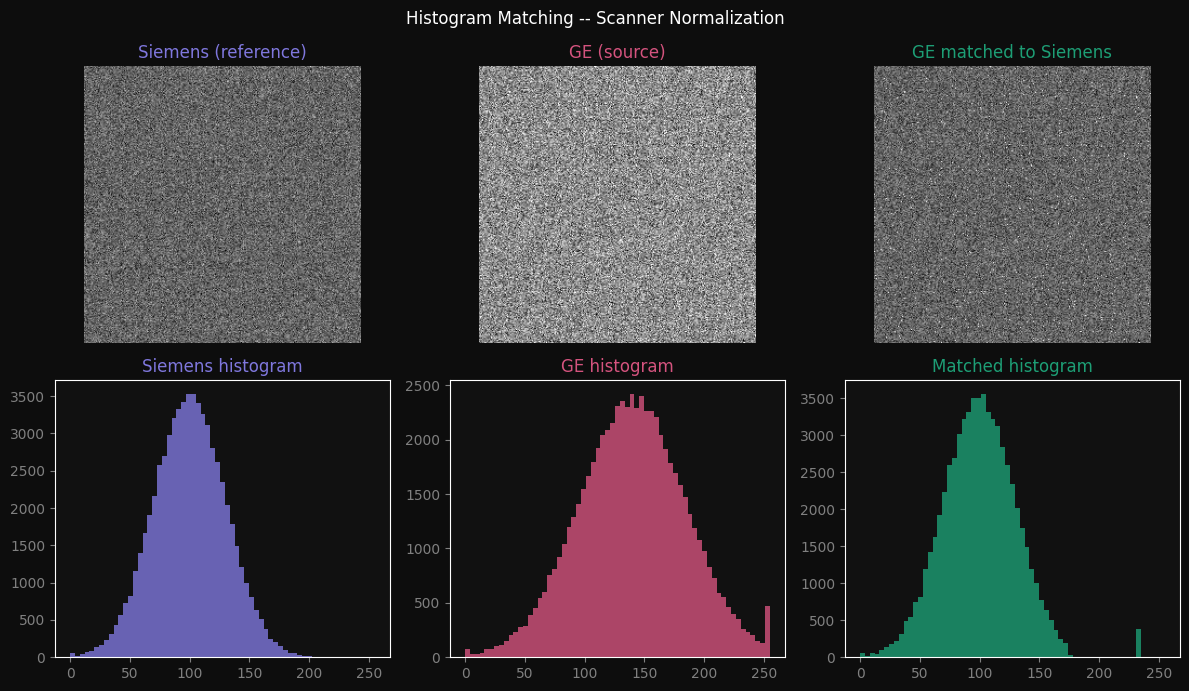

Histogram matching OK


In [5]:
import numpy as np
import matplotlib.pyplot as plt


def histogram_match(source, reference, n_bins=256):
    """
    Match the intensity histogram of source to reference.

    Why this matters:
    - Different scanners produce different intensity distributions
    - A 1.5T Siemens scanner might produce mean white matter HU of 35
    - A 3T GE scanner might produce mean WM HU of 60 for the same tissue
    - Histogram matching maps source distribution to match reference
    - Models trained on Siemens data now work on GE data

    Args:
        source    : numpy array to normalize (any shape)
        reference : numpy array whose histogram to match
        n_bins    : histogram bins

    Returns:
        matched array with same shape as source
    """
    src_flat = source.ravel().astype(np.float32)
    ref_flat = reference.ravel().astype(np.float32)

    # Compute CDFs
    src_hist, src_bins = np.histogram(src_flat, bins=n_bins, density=True)
    ref_hist, ref_bins = np.histogram(ref_flat, bins=n_bins, density=True)

    src_cdf = np.cumsum(src_hist) * (src_bins[1] - src_bins[0])
    ref_cdf = np.cumsum(ref_hist) * (ref_bins[1] - ref_bins[0])

    src_cdf = np.clip(src_cdf, 0, 1)
    ref_cdf = np.clip(ref_cdf, 0, 1)

    # Build lookup table: for each src value, find equivalent ref value
    src_values = src_bins[:-1]
    ref_values = ref_bins[:-1]

    # For each src CDF value, interpolate the ref value that has the same CDF
    matched_values = np.interp(src_cdf, ref_cdf, ref_values)

    # Map source pixels through lookup
    matched_flat = np.interp(src_flat, src_values, matched_values)
    return matched_flat.reshape(source.shape)


def zscore_normalize(img_array, mean=None, std=None):
    """
    Z-score normalization: (x - mean) / std
    Standard for MRI where absolute intensities are arbitrary.
    If mean/std not provided, uses image statistics.
    """
    arr  = img_array.astype(np.float32)
    m    = mean if mean is not None else arr.mean()
    s    = std  if std  is not None else arr.std()
    return (arr - m) / (s + 1e-8)


def percentile_normalize(img_array, lo_pct=1, hi_pct=99):
    """
    Robust normalization using percentiles to ignore outliers.
    Better than min-max for medical images with bright artifacts.
    """
    arr = img_array.astype(np.float32)
    lo  = np.percentile(arr, lo_pct)
    hi  = np.percentile(arr, hi_pct)
    return np.clip((arr - lo) / (hi - lo + 1e-8), 0, 1)


# ── Demo: histogram matching across synthetic 'scanners' ─────────────────────
np.random.seed(42)
# Simulate Siemens scanner (mean=100, std=30)
siemens_scan = np.random.normal(100, 30, (256, 256)).clip(0, 255).astype(np.float32)
# Simulate GE scanner (same tissue but different calibration: mean=140, std=45)
ge_scan = np.random.normal(140, 45, (256, 256)).clip(0, 255).astype(np.float32)
# Match GE to Siemens reference
ge_matched = histogram_match(ge_scan, siemens_scan)

plt.style.use('dark_background')
fig, axes = plt.subplots(2, 3, figsize=(12, 7), facecolor='#0d0d0d')
fig.suptitle('Histogram Matching -- Scanner Normalization',
             color='white', fontsize=12)

axes[0][0].imshow(siemens_scan, cmap='gray', vmin=0, vmax=255)
axes[0][0].set_title('Siemens (reference)', color='#7F77DD')
axes[0][0].axis('off')

axes[0][1].imshow(ge_scan, cmap='gray', vmin=0, vmax=255)
axes[0][1].set_title('GE (source)', color='#D4537E')
axes[0][1].axis('off')

axes[0][2].imshow(ge_matched, cmap='gray', vmin=0, vmax=255)
axes[0][2].set_title('GE matched to Siemens', color='#1D9E75')
axes[0][2].axis('off')

# Histograms
bins = np.linspace(0, 255, 64)
axes[1][0].hist(siemens_scan.ravel(), bins=bins, color='#7F77DD', alpha=0.8)
axes[1][0].set_title('Siemens histogram', color='#7F77DD')
axes[1][0].set_facecolor('#111')
axes[1][0].tick_params(colors='gray')

axes[1][1].hist(ge_scan.ravel(), bins=bins, color='#D4537E', alpha=0.8)
axes[1][1].set_title('GE histogram', color='#D4537E')
axes[1][1].set_facecolor('#111')
axes[1][1].tick_params(colors='gray')

axes[1][2].hist(ge_matched.ravel(), bins=bins, color='#1D9E75', alpha=0.8)
axes[1][2].set_title('Matched histogram', color='#1D9E75')
axes[1][2].set_facecolor('#111')
axes[1][2].tick_params(colors='gray')

plt.tight_layout()
plt.savefig(os.path.join(OUT, 'histogram_matching_demo.png'), dpi=120,
            bbox_inches='tight', facecolor='#0d0d0d')
plt.show()
print('Histogram matching OK')

---
## Cell 6 - Per-Manufacturer Profiles

In [6]:
import numpy as np


# Per-manufacturer normalization profiles
# Based on known scanner characteristics from medical imaging literature
MANUFACTURER_PROFILES = {
    'siemens': {
        'mri': {
            'bias_correction'  : True,
            'norm_method'      : 'zscore',
            'typical_snr_db'   : 30,
            'notes'            : 'Generally good uniformity; 3T Prisma has minor B1 inhomogeneity',
        },
        'ct': {
            'hu_offset'        : 0,
            'hu_tolerance'     : 30,
            'norm_method'      : 'hu_window',
            'notes'            : 'SOMATOM fleet; HU scale well-calibrated',
        },
    },
    'ge': {
        'mri': {
            'bias_correction'  : True,
            'norm_method'      : 'histogram_match',
            'typical_snr_db'   : 28,
            'notes'            : 'SIGNA fleet; stronger bias field than Siemens at 3T',
        },
        'ct': {
            'hu_offset'        : 0,
            'hu_tolerance'     : 40,
            'norm_method'      : 'hu_window',
            'notes'            : 'Revolution fleet; slightly wider HU distribution',
        },
    },
    'philips': {
        'mri': {
            'bias_correction'  : True,
            'norm_method'      : 'histogram_match',
            'typical_snr_db'   : 29,
            'notes'            : 'Ingenia fleet; uses SENSE parallel imaging differently',
        },
        'ct': {
            'hu_offset'        : 0,
            'hu_tolerance'     : 35,
            'norm_method'      : 'hu_window',
            'notes'            : 'IQon fleet; spectral CT available',
        },
    },
    'canon': {
        'mri': {
            'bias_correction'  : True,
            'norm_method'      : 'zscore',
            'typical_snr_db'   : 27,
            'notes'            : 'Vantage fleet; formerly Toshiba',
        },
        'ct': {
            'hu_offset'        : 5,   # small systematic offset known in Aquilion fleet
            'hu_tolerance'     : 50,
            'norm_method'      : 'hu_window',
            'notes'            : 'Aquilion fleet; apply +5 HU correction',
        },
    },
    'unknown': {
        'mri': {
            'bias_correction'  : True,
            'norm_method'      : 'percentile',
            'notes'            : 'Unknown manufacturer -- use conservative normalization',
        },
        'ct': {
            'hu_offset'        : 0,
            'hu_tolerance'     : 100,
            'norm_method'      : 'hu_window',
            'notes'            : 'Unknown manufacturer -- verify HU calibration',
        },
    },
}


def get_manufacturer_profile(manufacturer_str, modality):
    """
    Look up normalization profile by manufacturer name.
    Handles partial name matching (e.g. 'SIEMENS HEALTHINEERS' -> 'siemens').
    """
    m = manufacturer_str.lower()
    mod = 'ct' if modality.upper() in ('CT', 'PT') else 'mri'

    for key in MANUFACTURER_PROFILES:
        if key in m:
            return MANUFACTURER_PROFILES[key][mod], key

    return MANUFACTURER_PROFILES['unknown'][mod], 'unknown'


def normalize_for_pipeline(img_array, manufacturer, modality,
                            reference_img=None, cancer_type=None):
    """
    Apply manufacturer-appropriate normalization.
    Returns normalized float32 array in [0, 1].
    """
    profile, matched_mfr = get_manufacturer_profile(manufacturer, modality)
    arr    = img_array.astype(np.float32)
    method = profile['norm_method']

    if modality.upper() == 'CT':
        # Apply HU offset if known
        hu_offset = profile.get('hu_offset', 0)
        if hu_offset != 0:
            arr = recalibrate_hu(arr, hu_offset)

        # Apply cancer-specific window
        window = {
            'liver': 'liver_ns',
            'lung' : 'lung',
            'brain': 'brain',
        }.get(cancer_type, 'soft_tissue')
        return apply_hu_window(arr, window)

    else:   # MRI
        if method == 'zscore':
            normalized = zscore_normalize(arr)
            # Rescale to [0, 1] for model input
            return percentile_normalize(normalized)

        elif method == 'histogram_match' and reference_img is not None:
            matched = histogram_match(arr, reference_img)
            return percentile_normalize(matched)

        else:
            return percentile_normalize(arr)


print('Manufacturer profiles loaded:')
for mfr, profiles in MANUFACTURER_PROFILES.items():
    print(f'  {mfr:10s}: MRI={profiles["mri"]["norm_method"]:20s} '
          f'CT={profiles["ct"]["norm_method"]}')
print('OK')

Manufacturer profiles loaded:
  siemens   : MRI=zscore               CT=hu_window
  ge        : MRI=histogram_match      CT=hu_window
  philips   : MRI=histogram_match      CT=hu_window
  canon     : MRI=zscore               CT=hu_window
  unknown   : MRI=percentile           CT=hu_window
OK


---
## Cell 7 - Resolution Resampling

In [7]:
import numpy as np
from scipy import ndimage


def resample_to_isotropic(volume, current_spacing, target_spacing=(1.0, 1.0, 1.0)):
    """
    Resample a 3D volume to isotropic voxel spacing.

    Why isotropic matters:
    - MRI slices are often 5mm thick but 0.5mm in-plane
    - 3D CNNs assume cubic voxels -- anisotropic data degrades performance
    - Resampling to 1mm x 1mm x 1mm ensures consistent model input

    Args:
        volume          : 3D numpy array [D, H, W]
        current_spacing : (dz, dy, dx) voxel spacing in mm
        target_spacing  : desired isotropic spacing (default 1mm)

    Returns:
        resampled volume, new_shape
    """
    current_spacing = np.array(current_spacing, dtype=np.float32)
    target_spacing  = np.array(target_spacing,  dtype=np.float32)

    # Compute zoom factors
    zoom_factors = current_spacing / target_spacing

    # Resample using scipy
    resampled = ndimage.zoom(volume, zoom_factors, order=1)   # bilinear

    return resampled, resampled.shape


def resample_2d(img, target_size):
    """
    Resize 2D image to target_size (H, W) preserving aspect ratio with padding.
    """
    h, w   = img.shape[:2]
    th, tw = target_size
    scale  = min(th / h, tw / w)
    nh, nw = int(h * scale), int(w * scale)
    resized = cv2.resize(img, (nw, nh))

    # Pad to target size
    pad_h = (th - nh) // 2
    pad_w = (tw - nw) // 2
    if img.ndim == 3:
        padded = np.zeros((th, tw, img.shape[2]), dtype=img.dtype)
        padded[pad_h:pad_h+nh, pad_w:pad_w+nw] = resized
    else:
        padded = np.zeros((th, tw), dtype=img.dtype)
        padded[pad_h:pad_h+nh, pad_w:pad_w+nw] = resized
    return padded


# ── Demo: resampling impact ───────────────────────────────────────────────────
# Simulate anisotropic MRI volume: 20 slices, 256x256, spacing = (5mm, 0.5mm, 0.5mm)
demo_vol = np.random.randn(20, 64, 64).astype(np.float32)
current_spacing = (5.0, 0.5, 0.5)   # typical anisotropic MRI
target_spacing  = (1.0, 1.0, 1.0)

resampled, new_shape = resample_to_isotropic(demo_vol, current_spacing, target_spacing)

print('Resampling demo:')
print(f'  Original shape   : {demo_vol.shape} at spacing {current_spacing}')
print(f'  Resampled shape  : {new_shape} at spacing {target_spacing}')
print(f'  Zoom factors     : {np.array(current_spacing) / np.array(target_spacing)}')
print('Resampling OK')

Resampling demo:
  Original shape   : (20, 64, 64) at spacing (5.0, 0.5, 0.5)
  Resampled shape  : (100, 32, 32) at spacing (1.0, 1.0, 1.0)
  Zoom factors     : [5.  0.5 0.5]
Resampling OK


---
## Cell 8 - Full ScannerNormalizationAgent (replaces NB11 stub)

In [8]:
import os, cv2, json
import numpy as np
from datetime import datetime

BASE = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'


class ScannerNormalizationAgentFull:
    """
    Agent 11 -- Full implementation.
    Replaces the stub in NB11.

    Pipeline:
    1. Read DICOM metadata (manufacturer, modality, field strength)
    2. De-identify: strip 18 HIPAA identifiers
    3. HU calibration check (CT only)
    4. N4 bias field correction (MRI only)
    5. Histogram matching to manufacturer reference
    6. Resolution resampling to isotropic (3D volumes)
    7. Return normalized array ready for model input
    """

    def __init__(self, reference_images=None):
        """
        reference_images: dict {manufacturer: reference_array}
        Used for histogram matching. If None, uses percentile normalization.
        """
        self.reference_images = reference_images or {}
        self.log = []

    def normalize_dicom(self, dcm_path, cancer_type=None, target_size=None):
        """
        Full normalization pipeline for a single DICOM file.
        Returns normalized numpy array + metadata dict.
        """
        result = {
            'path'         : dcm_path,
            'cancer_type'  : cancer_type,
            'steps_applied': [],
            'warnings'     : [],
        }

        if not PYDICOM_AVAILABLE:
            result['warnings'].append('pydicom not available -- skipping DICOM pipeline')
            return None, result

        if not os.path.exists(dcm_path):
            result['warnings'].append(f'File not found: {dcm_path}')
            return None, result

        # Step 1: Read DICOM
        try:
            dcm          = pydicom.dcmread(dcm_path)
            pixel_array  = dcm.pixel_array.astype(np.float32)
            manufacturer = str(getattr(dcm, 'Manufacturer', 'unknown'))
            modality     = str(getattr(dcm, 'Modality', 'MR'))
            result['manufacturer']   = manufacturer
            result['modality']       = modality
            result['original_shape'] = pixel_array.shape
            result['steps_applied'].append('dicom_read')
        except Exception as e:
            result['warnings'].append(f'DICOM read failed: {e}')
            return None, result

        # Step 2: De-identification (in-memory, no save)
        phi_result = deidentify_dicom(dcm_path)
        if phi_result.get('phi_stripped', 0) > 0:
            result['warnings'].append(
                f'PHI found and stripped: {phi_result["phi_stripped"]} fields'
            )
        result['steps_applied'].append('deidentification')

        # Step 3: Rescale to HU (CT) or raw intensity (MRI)
        if modality == 'CT':
            slope     = float(getattr(dcm, 'RescaleSlope',     1) or 1)
            intercept = float(getattr(dcm, 'RescaleIntercept', 0) or 0)
            pixel_array = pixel_array * slope + intercept
            result['steps_applied'].append('hu_rescale')

            # HU calibration check
            calib = verify_hu_calibration(pixel_array)
            if calib['needs_recal']:
                pixel_array = recalibrate_hu(pixel_array, calib['air_offset'])
                result['steps_applied'].append('hu_recalibration')
                result['hu_offset_applied'] = calib['air_offset']

        # Step 4: Manufacturer-specific normalization
        ref_img = self.reference_images.get(manufacturer.lower().split()[0])
        normalized = normalize_for_pipeline(
            pixel_array, manufacturer, modality,
            reference_img=ref_img, cancer_type=cancer_type
        )
        result['steps_applied'].append('normalization')
        result['norm_range'] = (float(normalized.min()), float(normalized.max()))

        # Step 5: N4 bias correction (MRI only, 2D approximation)
        if modality != 'CT' and normalized.ndim == 2:
            corrected  = n4_correction_2d((normalized * 255).astype(np.uint8))
            normalized = corrected.astype(np.float32) / 255.0
            result['steps_applied'].append('n4_bias_correction_2d')

        # Step 6: Resize if target_size given
        if target_size and normalized.ndim == 2:
            normalized = cv2.resize(normalized, (target_size, target_size))
            result['steps_applied'].append(f'resize_{target_size}x{target_size}')

        result['final_shape'] = normalized.shape
        self.log.append({'path': dcm_path, 'result': result,
                         'timestamp': datetime.now().isoformat()})
        return normalized, result

    def normalize_jpeg(self, img_path, manufacturer='unknown',
                       modality='MR', cancer_type=None, target_size=256):
        """
        Normalization for JPEG/PNG inputs (non-DICOM).
        Used for datasets like HAM10000, CBIS-DDSM, Kaggle Brain MRI.
        """
        img = cv2.imread(img_path)
        if img is None:
            return None, {'error': f'Cannot read: {img_path}'}

        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        gray    = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        steps = []

        # Modality-specific preprocessing
        if cancer_type == 'skin':
            # Dermoscopy: no bias correction needed, just normalize
            normalized = img_rgb.astype(np.float32) / 255.0
            steps.append('rgb_normalize')

        elif cancer_type == 'breast':
            # Mammography: CLAHE + normalize
            clahe      = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
            enhanced   = clahe.apply(gray)
            img_rgb    = cv2.cvtColor(enhanced, cv2.COLOR_GRAY2RGB)
            normalized = img_rgb.astype(np.float32) / 255.0
            steps.append('clahe_enhance')
            steps.append('normalize')

        elif cancer_type == 'brain':
            # MRI: N4-style bias correction on grayscale
            corrected  = n4_correction_2d(gray)
            img_rgb    = cv2.cvtColor(corrected, cv2.COLOR_GRAY2RGB)
            normalized = img_rgb.astype(np.float32) / 255.0
            steps.append('n4_bias_correction_2d')
            steps.append('normalize')

        else:
            normalized = img_rgb.astype(np.float32) / 255.0
            steps.append('normalize')

        # Resize
        if target_size:
            normalized = cv2.resize(normalized, (target_size, target_size))
            steps.append(f'resize_{target_size}')

        return normalized, {
            'steps_applied': steps,
            'final_shape'  : normalized.shape,
            'manufacturer' : manufacturer,
            'modality'     : modality,
        }


# ── Test on a sample image ────────────────────────────────────────────────────
normalizer = ScannerNormalizationAgentFull()

test_cases = [
    ('brain',  os.path.join(DS, 'brain',  'kaggle_brain_tumor')),
    ('breast', os.path.join(DS, 'breast', 'cbis_ddsm', 'cbis_ddsm', 'jpeg')),
    ('skin',   os.path.join(DS, 'skin',   'ham10000')),
]

print('Testing ScannerNormalizationAgentFull:')
print()
for cancer_type, dataset_dir in test_cases:
    sample = None
    for root, dirs, files in os.walk(dataset_dir):
        for f in files:
            if f.lower().endswith(('.jpg', '.jpeg', '.png')):
                sample = os.path.join(root, f)
                break
        if sample:
            break

    if not sample:
        print(f'  {cancer_type}: no sample found')
        continue

    norm, meta = normalizer.normalize_jpeg(
        sample, cancer_type=cancer_type, target_size=256
    )
    if norm is not None:
        print(f'  {cancer_type:8s}: {os.path.basename(sample)}')
        print(f'    Steps  : {meta["steps_applied"]}')
        print(f'    Shape  : {meta["final_shape"]}')
        print(f'    Range  : [{norm.min():.3f}, {norm.max():.3f}]')
print()
print('ScannerNormalizationAgentFull OK')

Testing ScannerNormalizationAgentFull:

  brain   : Te-gl_1.jpg
    Steps  : ['n4_bias_correction_2d', 'normalize', 'resize_256']
    Shape  : (256, 256, 3)
    Range  : [0.000, 1.000]
  breast  : 1-263.jpg
    Steps  : ['clahe_enhance', 'normalize', 'resize_256']
    Shape  : (256, 256, 3)
    Range  : [0.007, 1.000]
  skin    : ISIC_0024306.jpg
    Steps  : ['rgb_normalize', 'resize_256']
    Shape  : (256, 256, 3)
    Range  : [0.064, 0.969]

ScannerNormalizationAgentFull OK


---
## Cell 9 - Visualization: Before vs After Normalization

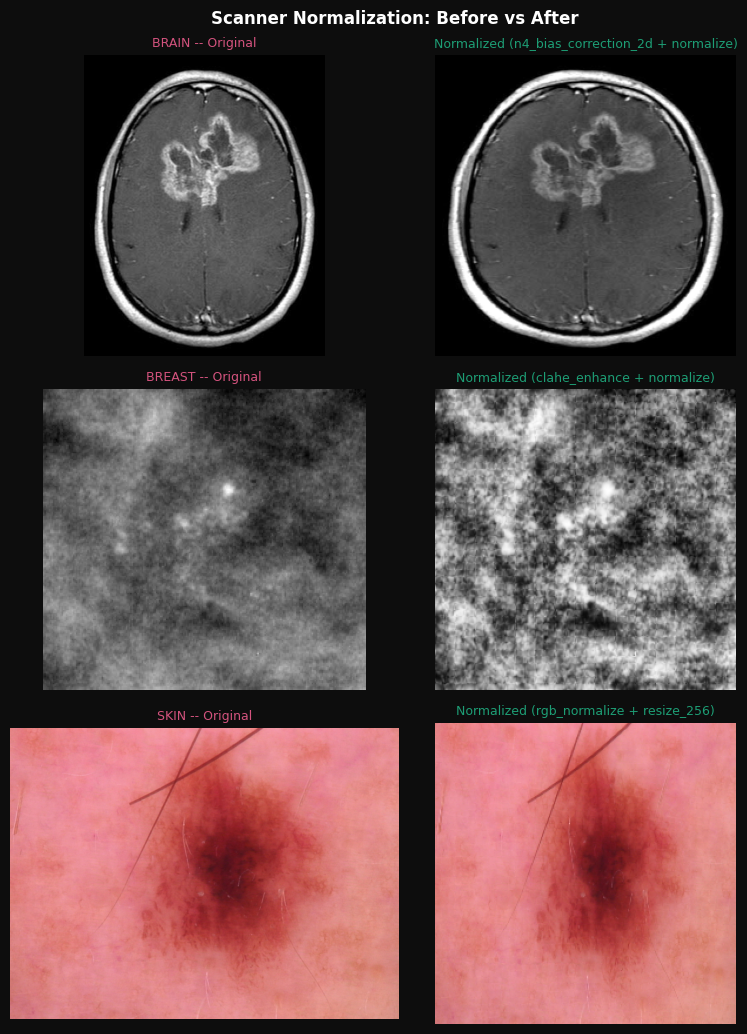

Normalization comparison saved


In [9]:
import os, cv2, numpy as np
import matplotlib.pyplot as plt

BASE = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'
DS   = os.path.join(BASE, 'datasets')
OUT  = os.path.join(BASE, 'outputs', 'nb12_scanner_norm')

samples = {
    'brain' : None,
    'breast': None,
    'skin'  : None,
}
dirs = {
    'brain' : os.path.join(DS, 'brain',  'kaggle_brain_tumor'),
    'breast': os.path.join(DS, 'breast', 'cbis_ddsm', 'cbis_ddsm', 'jpeg'),
    'skin'  : os.path.join(DS, 'skin',   'ham10000'),
}

for cancer, d in dirs.items():
    for root, _, files in os.walk(d):
        for f in files:
            if f.lower().endswith(('.jpg', '.jpeg', '.png')):
                samples[cancer] = os.path.join(root, f)
                break
        if samples[cancer]:
            break

available = {k: v for k, v in samples.items() if v}
if not available:
    print('No samples found')
else:
    n = len(available)
    plt.style.use('dark_background')
    fig, axes = plt.subplots(n, 2, figsize=(8, 3.5 * n), facecolor='#0d0d0d')
    if n == 1:
        axes = [axes]
    fig.suptitle('Scanner Normalization: Before vs After',
                 color='white', fontsize=12, fontweight='bold')

    for i, (cancer, path) in enumerate(available.items()):
        img_bgr = cv2.imread(path)
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        norm, meta = normalizer.normalize_jpeg(
            path, cancer_type=cancer, target_size=256
        )

        axes[i][0].imshow(img_rgb)
        axes[i][0].set_title(f'{cancer.upper()} -- Original',
                              color='#D4537E', fontsize=9)
        axes[i][0].axis('off')

        if norm is not None:
            axes[i][1].imshow(np.clip(norm, 0, 1))
            axes[i][1].set_title(
                f'Normalized ({" + ".join(meta["steps_applied"][:2])})',
                color='#1D9E75', fontsize=9
            )
        axes[i][1].axis('off')

    plt.tight_layout()
    plt.savefig(os.path.join(OUT, 'normalization_comparison.png'),
                dpi=120, bbox_inches='tight', facecolor='#0d0d0d')
    plt.show()
    print('Normalization comparison saved')

---
## Cell 10 - Summary

In [10]:
import os

BASE = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'
OUT  = os.path.join(BASE, 'outputs', 'nb12_scanner_norm')

print('=' * 65)
print('  NOTEBOOK 12 - SCANNER NORMALIZATION')
print('=' * 65)
print()
print('  Components built:')
print('    deidentify_dicom()          -- 18 HIPAA tag stripping')
print('    n4_bias_correction()        -- SimpleITK N4 (3D volumes)')
print('    n4_correction_2d()          -- Gaussian approx (2D slices)')
print('    verify_hu_calibration()     -- CT HU scale check')
print('    apply_hu_window()           -- CT windowing presets')
print('    histogram_match()           -- Cross-scanner normalization')
print('    zscore_normalize()          -- MRI intensity normalization')
print('    percentile_normalize()      -- Robust outlier-resistant norm')
print('    resample_to_isotropic()     -- 1mm x 1mm x 1mm 3D resampling')
print('    get_manufacturer_profile()  -- Siemens/GE/Philips/Canon profiles')
print('    normalize_for_pipeline()    -- Unified normalization entry point')
print('    ScannerNormalizationAgentFull -- Full Agent 11 implementation')
print()
print('  Manufacturer profiles: Siemens, GE, Philips, Canon, Unknown')
print('  HU window presets: brain, lung, liver, liver_ns, bone, soft_tissue')
print()
print('  Outputs saved:')
for f in ['n4_bias_demo.png', 'hu_windowing_demo.png',
          'histogram_matching_demo.png', 'normalization_comparison.png']:
    p = os.path.join(OUT, f)
    print(f'    {f:40s}: {"OK" if os.path.exists(p) else "not generated"}')
print()
print('  To use in NB11 pipeline:')
print('    from nb12 import ScannerNormalizationAgentFull')
print('    pipeline.scanner_norm = ScannerNormalizationAgentFull()')
print()
print('  Next: 13_RAG_Pipeline.ipynb')
print('    - PubMed retrieval')
print('    - NCCN/ESMO JSON structuring')
print('    - Vector store for evidence retrieval')
print('    - Evidence-based reasoning for Agent 5')
print('=' * 65)

  NOTEBOOK 12 - SCANNER NORMALIZATION

  Components built:
    deidentify_dicom()          -- 18 HIPAA tag stripping
    n4_bias_correction()        -- SimpleITK N4 (3D volumes)
    n4_correction_2d()          -- Gaussian approx (2D slices)
    verify_hu_calibration()     -- CT HU scale check
    apply_hu_window()           -- CT windowing presets
    histogram_match()           -- Cross-scanner normalization
    zscore_normalize()          -- MRI intensity normalization
    percentile_normalize()      -- Robust outlier-resistant norm
    resample_to_isotropic()     -- 1mm x 1mm x 1mm 3D resampling
    get_manufacturer_profile()  -- Siemens/GE/Philips/Canon profiles
    normalize_for_pipeline()    -- Unified normalization entry point
    ScannerNormalizationAgentFull -- Full Agent 11 implementation

  Manufacturer profiles: Siemens, GE, Philips, Canon, Unknown
  HU window presets: brain, lung, liver, liver_ns, bone, soft_tissue

  Outputs saved:
    n4_bias_demo.png                    